In [14]:
# Import libraries for data handling
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries for preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Import regression model classes
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Miscellaneous utilities
import time
import warnings
warnings.filterwarnings("ignore")   # hide unnecessary warning messages

# Set default plot style and figure size for consistent, readable plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("All libraries imported successfully.")


All libraries imported successfully.


In [15]:
# NOTE: You can change this path if your dataset is stored elsewhere
DATASET_PATH = "loan_data.csv"

# Load the dataset into a pandas DataFrame
df = pd.read_csv(DATASET_PATH)

# Confirm that the dataset has loaded correctly
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")


Dataset loaded successfully with 30000 rows and 24 columns.


In [16]:
# Shape of the dataset
print("Shape of dataset (rows, columns):", df.shape)

# Column names
print("\nColumn names:")
print(df.columns.tolist())

# First 5 rows
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Data types of each column
print("\nData types of each column:")
print(df.dtypes)

# Missing values in each column
print("\nMissing values in each column:")
print(df.isnull().sum())


Shape of dataset (rows, columns): (30000, 24)

Column names:
['Customer ID', 'Name', 'Gender', 'Age', 'Income (USD)', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Expense Type 1', 'Expense Type 2', 'Dependents', 'Credit Score', 'No. of Defaults', 'Has Active Credit Card', 'Property ID', 'Property Age', 'Property Type', 'Property Location', 'Co-Applicant', 'Property Price', 'Loan Sanction Amount (USD)']

First 5 rows of the dataset:


,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28



Data types of each column:
Customer ID                     object
Name                            object
Gender                          object
Age                              int64
Income (USD)                   float64
Income Stability                object
Profession                      object
Type of Employment              object
Location                        object
Loan Amount Request (USD)      float64
Current Loan Expenses (USD)    float64
Expense Type 1                  object
Expense Type 2                  object
Dependents                     float64
Credit Score                   float64
No. of Defaults                  int64
Has Active Credit Card          object
Property ID                      int64
Property Age                   float64
Property Type                    int64
Property Location               object
Co-Applicant                     int64
Property Price                 float64
Loan Sanction Amount (USD)     float64
dtype: object

Missing values in eac

In [17]:
# ------------------------------------------------------------------
# Step 1: Identify the target column automatically
# ------------------------------------------------------------------
# The target is the loan amount column. We search for likely column
# names automatically. If this fails to find the correct column,
# simply set TARGET_COLUMN manually to your dataset's exact column name.

possible_target_names = [
    "LoanAmount", "Loan_Amount", "loan_amount", "LoanAmountRequested",
    "Loan Amount", "loan_amount_requested", "Amount"
]

TARGET_COLUMN = None
for name in possible_target_names:
    if name in df.columns:
        TARGET_COLUMN = name
        break

# If not found automatically, fall back to any column containing "amount"
if TARGET_COLUMN is None:
    amount_cols = [c for c in df.columns if "amount" in c.lower()]
    if amount_cols:
        TARGET_COLUMN = amount_cols[0]

# ---- If auto-detection fails, set the correct column name manually here ----
# TARGET_COLUMN = "LoanAmount"

print("Target column detected:", TARGET_COLUMN)
assert TARGET_COLUMN is not None, "Please set TARGET_COLUMN manually to the loan amount column name."

# ------------------------------------------------------------------
# Step 2: Drop obvious ID columns (not useful for prediction)
# ------------------------------------------------------------------
id_like_cols = [c for c in df.columns if "id" == c.lower() or c.lower().endswith("_id")]
df_processed = df.drop(columns=id_like_cols, errors="ignore").copy()

# ------------------------------------------------------------------
# Step 3: Separate categorical and numerical columns (excluding target)
# ------------------------------------------------------------------
feature_columns = [c for c in df_processed.columns if c != TARGET_COLUMN]
categorical_cols = df_processed[feature_columns].select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = df_processed[feature_columns].select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

# ------------------------------------------------------------------
# Step 4: Handle missing values
# ------------------------------------------------------------------
# Fill missing numeric values with the median of that column
for col in numerical_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].median())

# Fill missing categorical values with the most frequent value (mode)
for col in categorical_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])

# Fill missing target values (if any) with the median target value
df_processed[TARGET_COLUMN] = df_processed[TARGET_COLUMN].fillna(df_processed[TARGET_COLUMN].median())

# ------------------------------------------------------------------
# Step 5: Encode categorical variables using Label Encoding
# ------------------------------------------------------------------
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le

print("\nMissing values after cleaning:")
print(df_processed.isnull().sum().sum(), "total missing values remaining.")

# ------------------------------------------------------------------
# Step 6: Separate features (X) and target (y)
# ------------------------------------------------------------------
X = df_processed[feature_columns]
y = df_processed[TARGET_COLUMN]

# ------------------------------------------------------------------
# Step 7: Feature scaling (apply to X only; y is left in original units
# so that error metrics like MAE/RMSE stay interpretable)
# ------------------------------------------------------------------
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("\nFinal shape of feature matrix X:", X_scaled.shape)
print("Final shape of target vector y:", y.shape)

display(X_scaled.head())


Target column detected: Loan Amount Request (USD)
Categorical columns: ['Customer ID', 'Name', 'Gender', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Expense Type 1', 'Expense Type 2', 'Has Active Credit Card', 'Property Location']
Numerical columns: ['Age', 'Income (USD)', 'Current Loan Expenses (USD)', 'Dependents', 'Credit Score', 'No. of Defaults', 'Property ID', 'Property Age', 'Property Type', 'Co-Applicant', 'Property Price', 'Loan Sanction Amount (USD)']

Missing values after cleaning:
0 total missing values remaining.

Final shape of feature matrix X: (30000, 23)
Final shape of target vector y: (30000,)


,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Current Loan Expenses (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,0.355706,-0.631679,-1.007092,0.991451,-0.061266,0.305833,0.834973,1.569338,0.142149,-0.660358,...,0.992493,-0.490502,-1.126689,0.846998,-0.060969,1.376731,-1.214540,0.076982,-0.126419,0.148002
1,0.124304,-1.581420,0.992958,-0.504355,0.229972,0.305833,0.834973,0.027732,0.142149,0.392886,...,0.578136,-0.490502,1.299777,0.368086,0.230298,-0.411309,-1.214540,0.076982,-0.822772,-0.209288
2,0.410207,1.107993,-1.007092,1.552379,-0.152389,-3.269763,-0.686548,0.027732,0.142149,-0.946193,...,1.330799,-0.490502,1.299777,0.152923,-0.152102,-0.411309,1.283229,0.063579,-0.634103,-0.230044
3,-0.456511,1.715943,-1.007092,1.552379,-0.033357,-3.269763,-0.686548,0.027732,-1.762481,-0.422775,...,1.324379,2.038728,1.299777,1.346732,-0.032979,-0.411309,0.034344,0.076982,-0.110298,0.177886
4,-0.693802,-1.710054,-1.007092,-0.566680,0.004480,0.305833,0.834973,-0.486137,0.142149,0.374693,...,0.080879,2.038728,-1.126689,0.739417,0.004783,1.376731,0.034344,0.076982,0.821057,0.552492


## 5. Exploratory Data Analysis (EDA)

**Question:**
Perform exploratory data analysis by computing summary statistics and a correlation matrix, and note key observations.




Summary statistics:


,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Current Loan Expenses (USD),...,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD),Loan Amount Request (USD)
count,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,...,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,30000.000000
mean,1.421085e-18,9.473903e-19,-1.998994e-16,-1.011339e-16,-2.747432e-17,1.359505e-16,8.526513e-18,-1.515825e-17,-3.031649e-17,-8.242296e-17,...,4.168517e-17,1.316873e-16,-7.200166e-17,7.105427e-18,4.097463e-17,-5.400125e-17,-9.473903e-18,1.752672e-16,9.284425e-17,88826.333855
std,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,...,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,59536.949605
min,-1.731993e+00,-1.731993e+00,-1.007092e+00,-1.376908e+00,-2.112649e-01,-3.269763e+00,-1.827689e+00,-2.027743e+00,-1.762481e+00,-5.787773e+00,...,-4.905020e-01,-1.126689e+00,-1.738431e+00,-2.109841e-01,-1.305329e+00,-1.214540e+00,-1.332545e+01,-1.419151e+00,-1.011320e+00,6048.240000
25%,-8.659965e-01,-8.659965e-01,-1.007092e+00,-9.406314e-01,-7.956497e-02,3.058326e-01,-1.447309e+00,-4.861368e-01,1.421489e-01,-6.290369e-01,...,-4.905020e-01,-1.126689e+00,-8.708376e-01,-7.864286e-02,-1.305329e+00,-1.214540e+00,7.698176e-02,-7.609733e-01,-9.904923e-01,41177.755000
50%,0.000000e+00,0.000000e+00,9.929581e-01,-5.752621e-03,-3.335734e-02,3.058326e-01,8.349727e-01,2.773178e-02,1.421489e-01,-1.057848e-01,...,-4.905020e-01,8.654395e-02,7.167366e-03,-3.297946e-02,-4.113088e-01,3.434433e-02,7.698176e-02,-2.326728e-01,-2.564186e-01,75128.075000
75%,8.659965e-01,8.659965e-01,9.929581e-01,9.291261e-01,2.901157e-02,3.058326e-01,8.349727e-01,5.416004e-01,1.421489e-01,4.933296e-01,...,-4.905020e-01,1.299777e+00,8.643500e-01,2.742982e-02,4.827112e-01,1.283229e+00,7.698176e-02,5.037098e-01,5.473890e-01,119964.605000
max,1.731993e+00,1.731993e+00,9.929581e-01,1.552379e+00,1.711718e+02,3.058326e-01,8.349727e-01,2.340141e+00,2.046779e+00,1.422390e+01,...,2.038728e+00,1.299777e+00,1.725003e+00,1.711900e+02,1.376731e+00,1.283229e+00,7.698176e-02,1.011467e+01,9.056698e+00,621497.820000


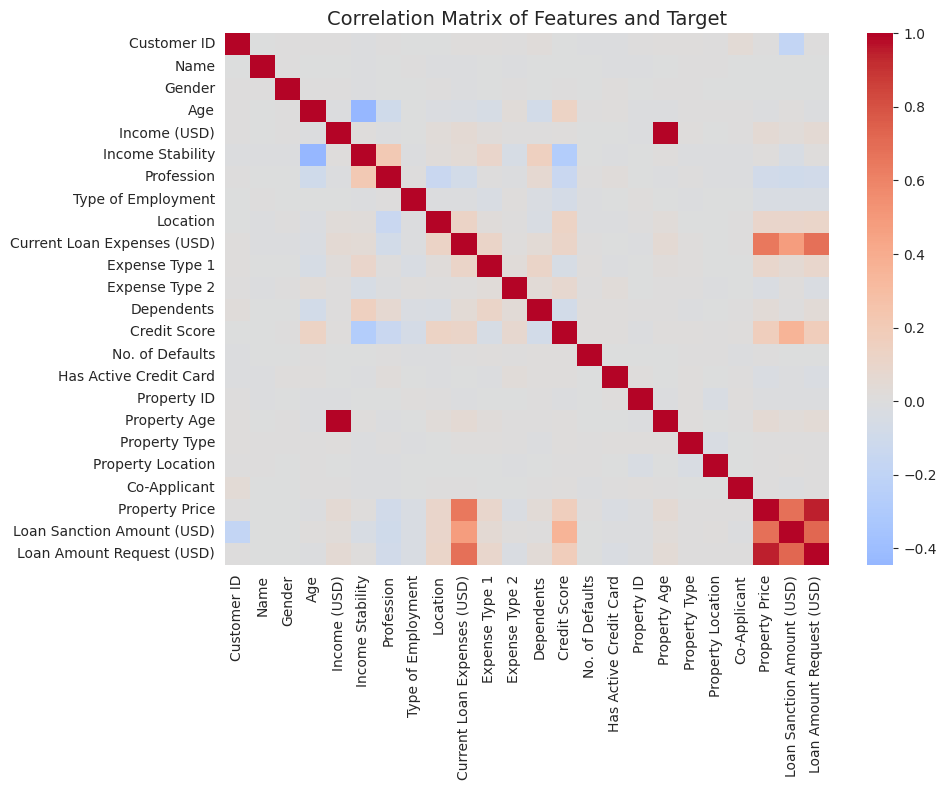


Feature correlation with target (sorted):
Property Price                 0.948350
Loan Sanction Amount (USD)     0.721181
Current Loan Expenses (USD)    0.680451
Credit Score                   0.173332
Location                       0.103902
Expense Type 1                 0.096134
Income (USD)                   0.045981
Property Age                   0.045425
Dependents                     0.039394
Income Stability               0.014013
Property Location              0.005710
Property Type                  0.003802
Customer ID                    0.002057
Co-Applicant                   0.001864
Gender                         0.000107
No. of Defaults                0.000088
Name                          -0.004154
Property ID                   -0.008426
Age                           -0.010450
Expense Type 2                -0.023596
Has Active Credit Card        -0.026222
Type of Employment            -0.030800
Profession                    -0.085669
Name: Loan Amount Request (USD), dtyp

In [18]:
# Combine scaled features with the target for correlation analysis
eda_df = X_scaled.copy()
eda_df[TARGET_COLUMN] = y.values

# Summary statistics of the dataset
print("Summary statistics:")
display(eda_df.describe())

# Correlation matrix
correlation_matrix = eda_df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Features and Target", fontsize=14)
plt.tight_layout()
plt.show()

# Print correlation of each feature with the target, sorted
target_correlation = correlation_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
print("\nFeature correlation with target (sorted):")
print(target_correlation)


**Observations:**
- Features with correlation values close to +1 or -1 with the target have a strong linear relationship with the loan amount, and are likely to be important predictors.
- Features with correlation close to 0 have little to no linear relationship with the target.
- If two features are highly correlated with each other (multicollinearity), regularized models (Ridge, Lasso, Elastic Net) usually handle this better than plain Linear Regression.


## 6. Target Variable Distribution Plot

**Question:**
Plot the distribution of the target variable (loan amount) to understand its spread and shape.


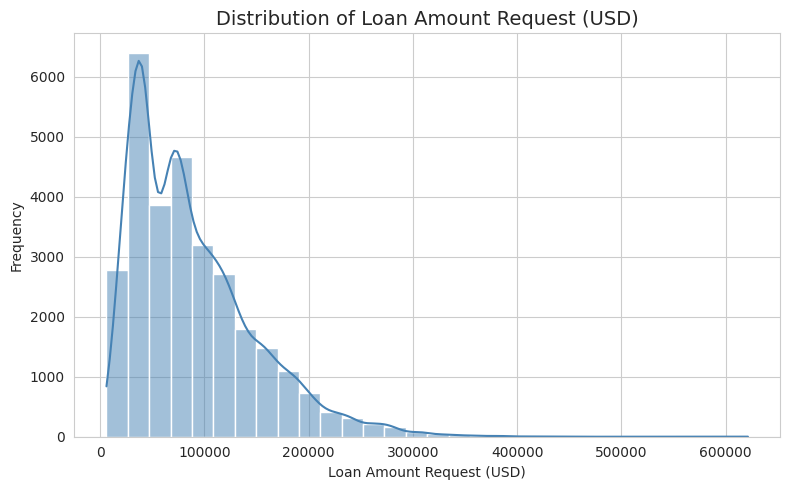

Mean Loan Amount Request (USD): 88826.33
Median Loan Amount Request (USD): 75128.07
Standard deviation: 59536.95


In [19]:
# Plot the distribution of the target variable (Loan Amount)
plt.figure(figsize=(8, 5))
sns.histplot(y, kde=True, bins=30, color="steelblue")
plt.title(f"Distribution of {TARGET_COLUMN}", fontsize=14)
plt.xlabel(TARGET_COLUMN)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"Mean {TARGET_COLUMN}: {y.mean():.2f}")
print(f"Median {TARGET_COLUMN}: {y.median():.2f}")
print(f"Standard deviation: {y.std():.2f}")


## 7. Feature vs Target Scatter Plots

**Question:**
Generate scatter plots of important numerical features against the target variable (loan amount) to visually inspect their relationship.



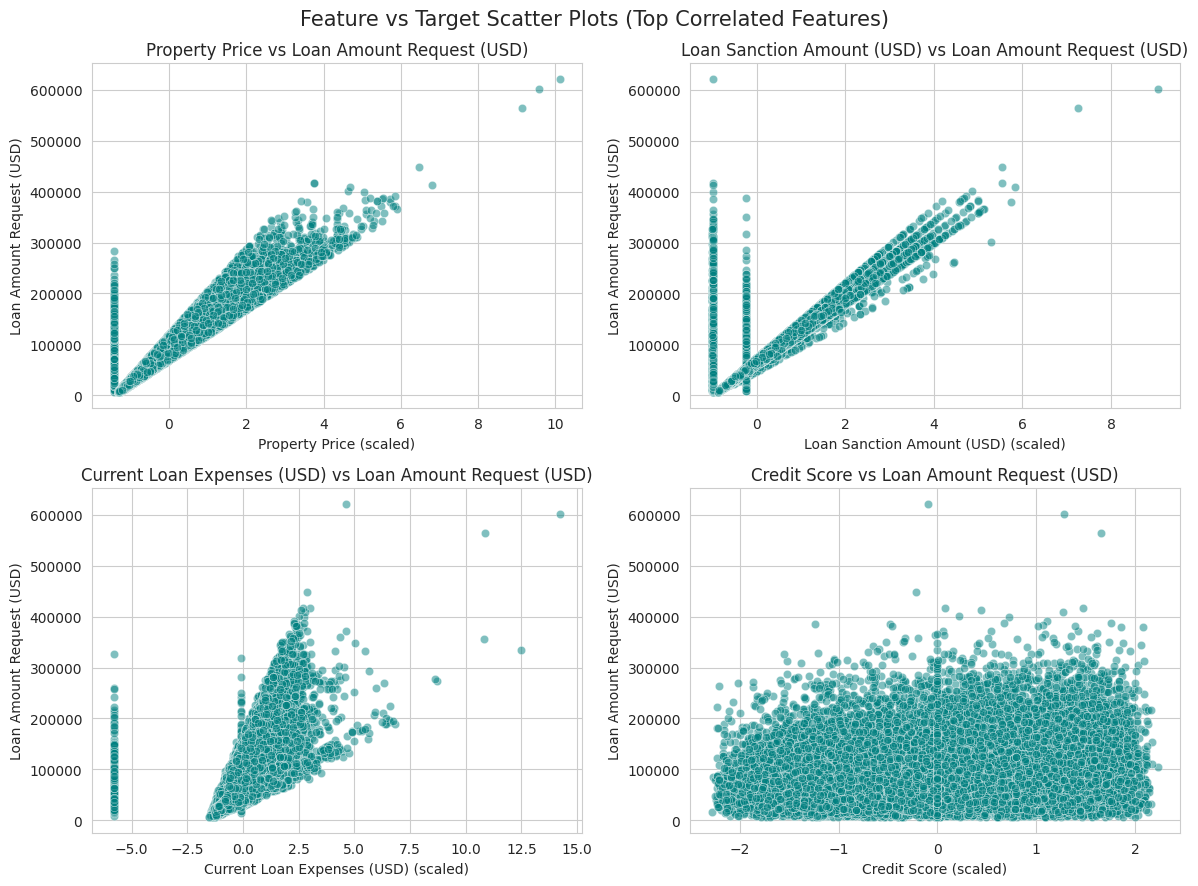

In [20]:
# Select the top 4 features most correlated (in magnitude) with the target
top_features = target_correlation.abs().sort_values(ascending=False).head(4).index.tolist()

# Create a grid of scatter plots: feature vs target
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.scatterplot(x=X_scaled[feature], y=y, ax=axes[i], alpha=0.5, color="teal")
    axes[i].set_title(f"{feature} vs {TARGET_COLUMN}", fontsize=12)
    axes[i].set_xlabel(f"{feature} (scaled)")
    axes[i].set_ylabel(TARGET_COLUMN)

plt.suptitle("Feature vs Target Scatter Plots (Top Correlated Features)", fontsize=15)
plt.tight_layout()
plt.show()


## 8. Train-Test Split

**Question:**
Split the dataset into training and testing sets so that model performance can be evaluated on unseen data.



In [21]:
# Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (24000, 23)
Testing set shape: (6000, 23)


## 9. Train Linear Regression Model

**Question:**
Train a Linear Regression model on the training data and use it to make predictions on the test data.




In [22]:
# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model and measure training time
start_time = time.time()
linear_model.fit(X_train, y_train)
linear_train_time = time.time() - start_time

# Make predictions on training and test data
y_train_pred_linear = linear_model.predict(X_train)
y_test_pred_linear = linear_model.predict(X_test)

print(f"Linear Regression trained in {linear_train_time:.4f} seconds.")
print("Sample predictions on test set:", y_test_pred_linear[:5])


Linear Regression trained in 0.0238 seconds.
Sample predictions on test set: [ 55001.61744195  79391.60709027 124476.66032706 125453.48616995
  48196.50043019]


## 10. Evaluate Linear Regression

**Question:**
Evaluate the Linear Regression model using MAE, MSE, RMSE, R² Score, and Training Time.




In [28]:
# Create a dictionary to store results of all models (used throughout the notebook)
results = {}

def evaluate_model(name, y_true, y_pred, train_time):
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    results[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Training Time (s)": train_time
    }

    print(f"--- {name} Evaluation (Test Set) ---")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print(f"Training Time: {train_time:.4f} seconds")

# Evaluate Linear Regression on the test set
evaluate_model("Linear Regression", y_test, y_test_pred_linear, linear_train_time)


--- Linear Regression Evaluation (Test Set) ---
MAE  : 11357.0900
MSE  : 349133012.7972
RMSE : 18685.1014
R2   : 0.9001
Training Time: 0.0238 seconds


## 11. Train Ridge Regression

**Question:**
Train a Ridge Regression model (with a default alpha value) on the training data.



In [29]:
# Create a Ridge Regression model with a default alpha value
ridge_model = Ridge(alpha=1.0, random_state=42)

# Train the model and measure training time
start_time = time.time()
ridge_model.fit(X_train, y_train)
ridge_train_time = time.time() - start_time

# Make predictions
y_train_pred_ridge = ridge_model.predict(X_train)
y_test_pred_ridge = ridge_model.predict(X_test)

print(f"Ridge Regression (default alpha=1.0) trained in {ridge_train_time:.4f} seconds.")


Ridge Regression (default alpha=1.0) trained in 0.0090 seconds.


## 12. Hyperparameter Tuning for Ridge

**Question:**
Use GridSearchCV with 5-Fold Cross-Validation to find the best alpha value for Ridge Regression from the search space {0.01, 0.1, 1, 10, 100}.




In [30]:
# Define the search space for Ridge alpha
ridge_param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}

# Set up 5-Fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Set up Grid Search for Ridge Regression
ridge_grid_search = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=ridge_param_grid,
    cv=kfold,
    scoring="r2",
    n_jobs=-1
)

# Perform the grid search on training data
ridge_grid_search.fit(X_train, y_train)

# Best alpha value and best cross-validation score
best_ridge_alpha = ridge_grid_search.best_params_["alpha"]
best_ridge_cv_score = ridge_grid_search.best_score_

print("Best alpha for Ridge Regression:", best_ridge_alpha)
print(f"Best cross-validation R2 score: {best_ridge_cv_score:.4f}")


Best alpha for Ridge Regression: 10
Best cross-validation R2 score: 0.9165


## 13. Evaluate Ridge Regression

**Question:**
Train the final Ridge Regression model using the best alpha found, and evaluate it on the test set.




In [31]:
# Train the final Ridge model using the best alpha value
ridge_best_model = Ridge(alpha=best_ridge_alpha, random_state=42)

start_time = time.time()
ridge_best_model.fit(X_train, y_train)
ridge_best_train_time = time.time() - start_time

# Predict on train and test sets
y_train_pred_ridge = ridge_best_model.predict(X_train)
y_test_pred_ridge = ridge_best_model.predict(X_test)

# Evaluate the tuned Ridge model
evaluate_model("Ridge Regression", y_test, y_test_pred_ridge, ridge_best_train_time)


--- Ridge Regression Evaluation (Test Set) ---
MAE  : 11358.9479
MSE  : 348475430.0743
RMSE : 18667.4966
R2   : 0.9003
Training Time: 0.0061 seconds


## 14. Train Lasso Regression

**Question:**
Train a Lasso Regression model (with a default alpha value) on the training data.



In [32]:
# Create a Lasso Regression model with a default alpha value
lasso_model = Lasso(alpha=1.0, random_state=42, max_iter=10000)

# Train the model and measure training time
start_time = time.time()
lasso_model.fit(X_train, y_train)
lasso_train_time = time.time() - start_time

# Make predictions
y_train_pred_lasso = lasso_model.predict(X_train)
y_test_pred_lasso = lasso_model.predict(X_test)

print(f"Lasso Regression (default alpha=1.0) trained in {lasso_train_time:.4f} seconds.")


Lasso Regression (default alpha=1.0) trained in 0.1847 seconds.


## 15. Hyperparameter Tuning for Lasso

**Question:**
Use GridSearchCV with 5-Fold Cross-Validation to find the best alpha value for Lasso Regression from the search space {0.001, 0.01, 0.1, 1, 10}.



In [33]:
# Define the search space for Lasso alpha
lasso_param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10]}

# Set up Grid Search for Lasso Regression (reusing the same 5-fold splitter)
lasso_grid_search = GridSearchCV(
    estimator=Lasso(random_state=42, max_iter=10000),
    param_grid=lasso_param_grid,
    cv=kfold,
    scoring="r2",
    n_jobs=-1
)

# Perform the grid search on training data
lasso_grid_search.fit(X_train, y_train)

# Best alpha value and best cross-validation score
best_lasso_alpha = lasso_grid_search.best_params_["alpha"]
best_lasso_cv_score = lasso_grid_search.best_score_

print("Best alpha for Lasso Regression:", best_lasso_alpha)
print(f"Best cross-validation R2 score: {best_lasso_cv_score:.4f}")


Best alpha for Lasso Regression: 10
Best cross-validation R2 score: 0.9165


## 16. Evaluate Lasso Regression

**Question:**
Train the final Lasso Regression model using the best alpha found, and evaluate it on the test set.



In [34]:
# Train the final Lasso model using the best alpha value
lasso_best_model = Lasso(alpha=best_lasso_alpha, random_state=42, max_iter=10000)

start_time = time.time()
lasso_best_model.fit(X_train, y_train)
lasso_best_train_time = time.time() - start_time

# Predict on train and test sets
y_train_pred_lasso = lasso_best_model.predict(X_train)
y_test_pred_lasso = lasso_best_model.predict(X_test)

# Evaluate the tuned Lasso model
evaluate_model("Lasso Regression", y_test, y_test_pred_lasso, lasso_best_train_time)


--- Lasso Regression Evaluation (Test Set) ---
MAE  : 11346.2351
MSE  : 334531858.3147
RMSE : 18290.2121
R2   : 0.9043
Training Time: 0.0862 seconds


## 17. Train Elastic Net Regression

**Question:**
Train an Elastic Net Regression model (with default alpha and l1_ratio values) on the training data.




In [35]:
# Create an Elastic Net model with default alpha and l1_ratio
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000)

# Train the model and measure training time
start_time = time.time()
elastic_model.fit(X_train, y_train)
elastic_train_time = time.time() - start_time

# Make predictions
y_train_pred_elastic = elastic_model.predict(X_train)
y_test_pred_elastic = elastic_model.predict(X_test)

print(f"Elastic Net (default alpha=1.0, l1_ratio=0.5) trained in {elastic_train_time:.4f} seconds.")


Elastic Net (default alpha=1.0, l1_ratio=0.5) trained in 0.1023 seconds.


## 18. Hyperparameter Tuning for Elastic Net

**Question:**
Use GridSearchCV with 5-Fold Cross-Validation to find the best alpha and l1_ratio for Elastic Net from the search space alpha = {0.01, 0.1, 1, 10} and l1_ratio = {0.2, 0.5, 0.8}.




In [36]:
# Define the search space for Elastic Net (alpha and l1_ratio)
elastic_param_grid = {
    "alpha": [0.01, 0.1, 1, 10],
    "l1_ratio": [0.2, 0.5, 0.8]
}

# Set up Grid Search for Elastic Net Regression
elastic_grid_search = GridSearchCV(
    estimator=ElasticNet(random_state=42, max_iter=10000),
    param_grid=elastic_param_grid,
    cv=kfold,
    scoring="r2",
    n_jobs=-1
)

# Perform the grid search on training data
elastic_grid_search.fit(X_train, y_train)

# Best hyperparameter combination and best cross-validation score
best_elastic_params = elastic_grid_search.best_params_
best_elastic_cv_score = elastic_grid_search.best_score_

print("Best parameters for Elastic Net Regression:", best_elastic_params)
print(f"Best cross-validation R2 score: {best_elastic_cv_score:.4f}")


Best parameters for Elastic Net Regression: {'alpha': 0.01, 'l1_ratio': 0.8}
Best cross-validation R2 score: 0.9165


## 19. Evaluate Elastic Net

**Question:**
Train the final Elastic Net model using the best alpha and l1_ratio found, and evaluate it on the test set.



In [37]:
# Train the final Elastic Net model using the best hyperparameters
elastic_best_model = ElasticNet(
    alpha=best_elastic_params["alpha"],
    l1_ratio=best_elastic_params["l1_ratio"],
    random_state=42,
    max_iter=10000
)

start_time = time.time()
elastic_best_model.fit(X_train, y_train)
elastic_best_train_time = time.time() - start_time

# Predict on train and test sets
y_train_pred_elastic = elastic_best_model.predict(X_train)
y_test_pred_elastic = elastic_best_model.predict(X_test)

# Evaluate the tuned Elastic Net model
evaluate_model("Elastic Net", y_test, y_test_pred_elastic, elastic_best_train_time)


--- Elastic Net Evaluation (Test Set) ---
MAE  : 11365.7532
MSE  : 346698498.0680
RMSE : 18619.8415
R2   : 0.9008
Training Time: 0.0219 seconds


## 20. Predicted vs Actual Plot

**Question:**
Generate Predicted vs. Actual plots for all four models to visually compare how close predictions are to true values.


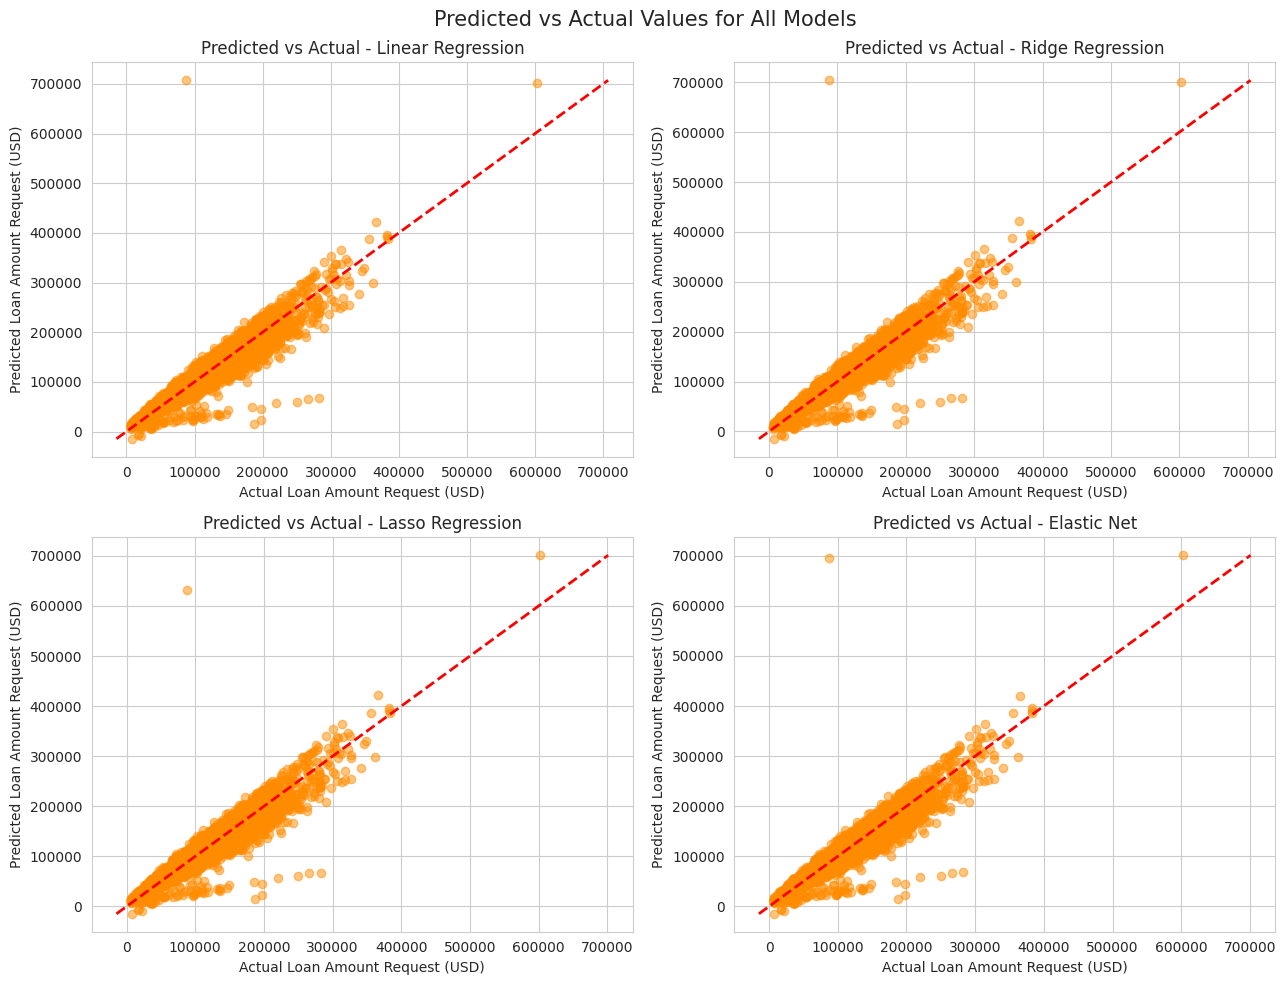

In [38]:
# Collect final test-set predictions from all four tuned models
model_predictions = {
    "Linear Regression": y_test_pred_linear,
    "Ridge Regression": y_test_pred_ridge,
    "Lasso Regression": y_test_pred_lasso,
    "Elastic Net": y_test_pred_elastic
}

# Create a 2x2 grid of Predicted vs Actual plots
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, (model_name, predictions) in enumerate(model_predictions.items()):
    axes[i].scatter(y_test, predictions, alpha=0.5, color="darkorange")

    # Draw the perfect-prediction diagonal line
    min_val = min(y_test.min(), predictions.min())
    max_val = max(y_test.max(), predictions.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)

    axes[i].set_title(f"Predicted vs Actual - {model_name}", fontsize=12)
    axes[i].set_xlabel("Actual " + TARGET_COLUMN)
    axes[i].set_ylabel("Predicted " + TARGET_COLUMN)

plt.suptitle("Predicted vs Actual Values for All Models", fontsize=15)
plt.tight_layout()
plt.show()


## 21. Residual Plot

**Question:**
Generate residual plots for all four models to check whether prediction errors are random or show a pattern.



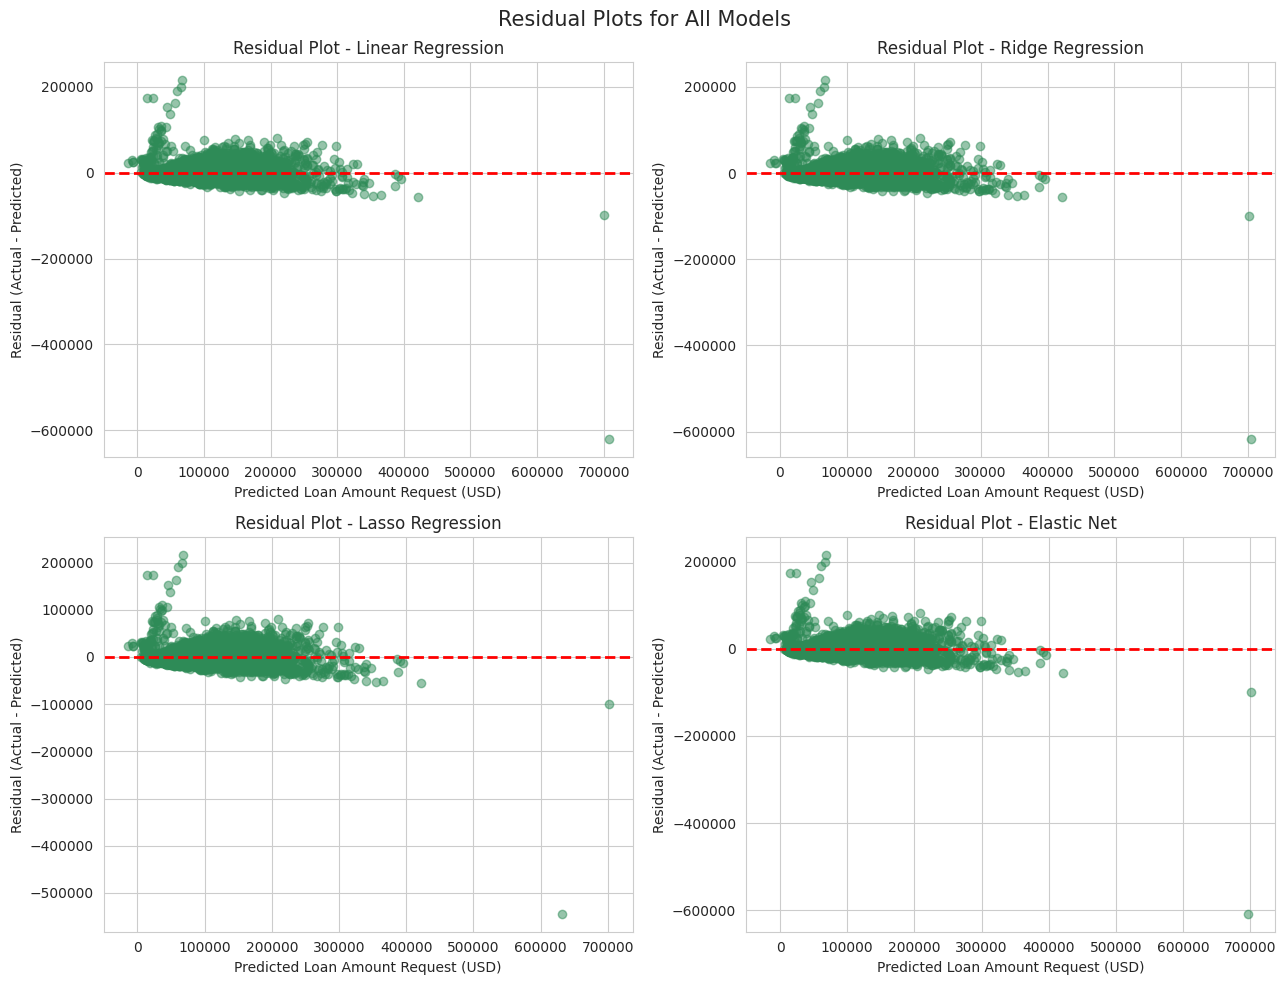

In [39]:
# Create a 2x2 grid of Residual plots
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, (model_name, predictions) in enumerate(model_predictions.items()):
    residuals = y_test - predictions

    axes[i].scatter(predictions, residuals, alpha=0.5, color="seagreen")
    axes[i].axhline(y=0, color="red", linestyle="--", linewidth=2)

    axes[i].set_title(f"Residual Plot - {model_name}", fontsize=12)
    axes[i].set_xlabel("Predicted " + TARGET_COLUMN)
    axes[i].set_ylabel("Residual (Actual - Predicted)")

plt.suptitle("Residual Plots for All Models", fontsize=15)
plt.tight_layout()
plt.show()


## 22. Training Error vs Validation Error Plot

**Question:**
Compare training error and validation (test) error for all four models using a bar plot.




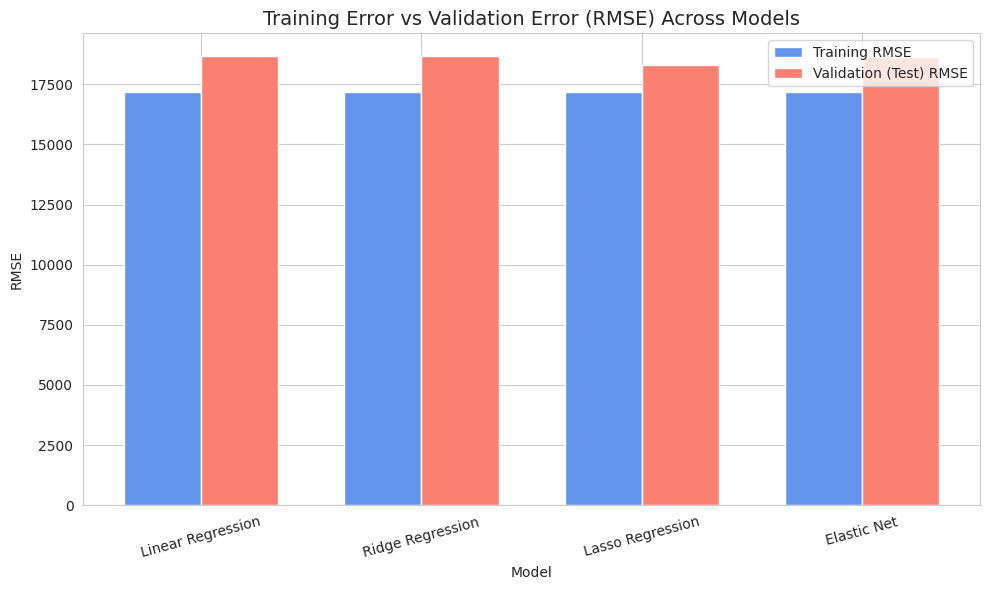

,Model,Training RMSE,Validation RMSE
0,Linear Regression,17177.926730,18685.101359
1,Ridge Regression,17177.973658,18667.496620
2,Lasso Regression,17178.115670,18290.212090
3,Elastic Net,17178.431575,18619.841516


In [40]:
# Calculate training and test RMSE for each model
train_predictions = {
    "Linear Regression": y_train_pred_linear,
    "Ridge Regression": y_train_pred_ridge,
    "Lasso Regression": y_train_pred_lasso,
    "Elastic Net": y_train_pred_elastic
}

model_names = list(model_predictions.keys())
train_rmse_values = [np.sqrt(mean_squared_error(y_train, train_predictions[name])) for name in model_names]
test_rmse_values = [np.sqrt(mean_squared_error(y_test, model_predictions[name])) for name in model_names]

# Plot grouped bar chart: Training RMSE vs Test RMSE
x_positions = np.arange(len(model_names))
bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x_positions - bar_width/2, train_rmse_values, width=bar_width, label="Training RMSE", color="cornflowerblue")
plt.bar(x_positions + bar_width/2, test_rmse_values, width=bar_width, label="Validation (Test) RMSE", color="salmon")

plt.xticks(x_positions, model_names, rotation=15)
plt.title("Training Error vs Validation Error (RMSE) Across Models", fontsize=14)
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()

# Print the values in a table
error_comparison_df = pd.DataFrame({
    "Model": model_names,
    "Training RMSE": train_rmse_values,
    "Validation RMSE": test_rmse_values
})
display(error_comparison_df)


## 23. Coefficient Comparison Plot

**Question:**
Compare the coefficients learned by Linear, Ridge, Lasso, and Elastic Net models using a bar plot.


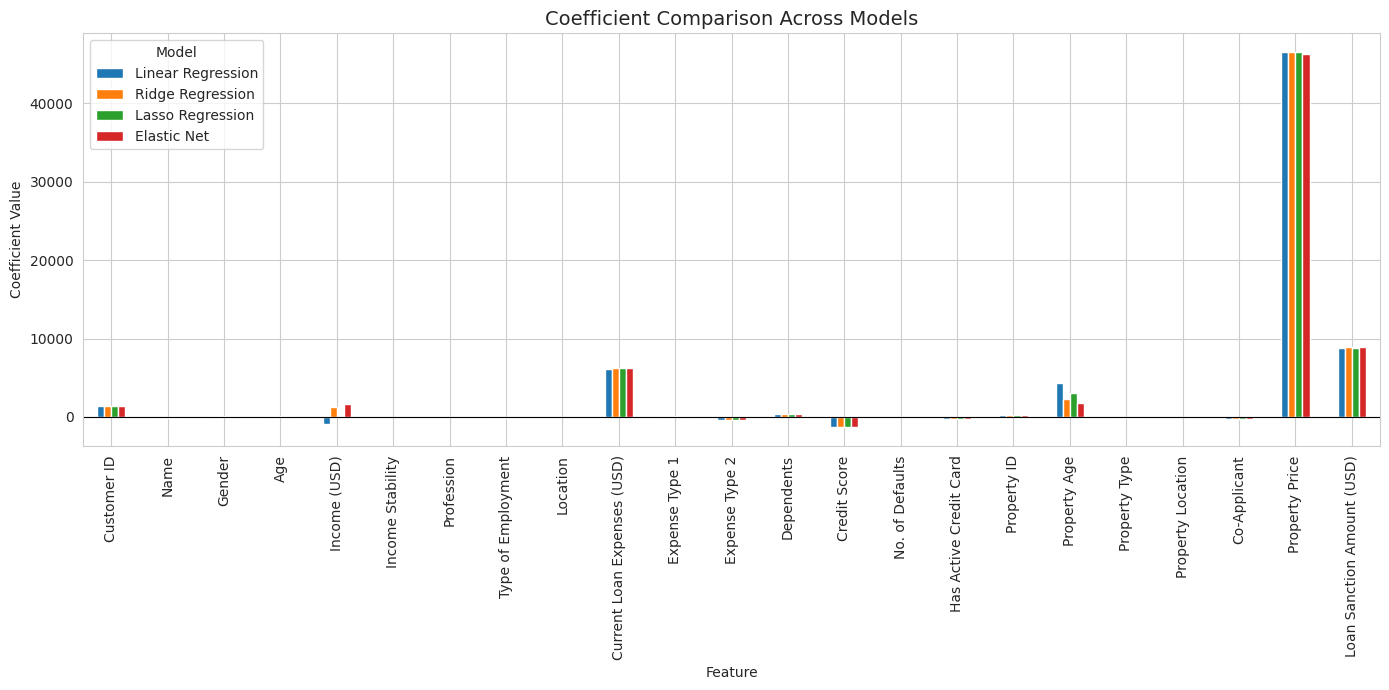

,Feature,Linear Regression,Ridge Regression,Lasso Regression,Elastic Net
0,Customer ID,1430.830090,1433.630927,1418.501813,1443.275677
1,Name,-152.068375,-151.779972,-142.456945,-151.433245
2,Gender,131.535746,131.606890,121.236435,131.992252
3,Age,170.389179,169.959295,151.398903,169.889577
4,Income (USD),-860.059537,1227.475042,0.000000,1593.728956
5,Income Stability,49.852607,50.274905,38.865843,52.159561
6,Profession,-37.779558,-38.592873,-28.766012,-42.000186
7,Type of Employment,-183.458543,-183.935323,-173.342850,-185.286385
8,Location,-19.627894,-19.439500,-0.251934,-16.827985
9,Current Loan Expenses (USD),6170.816761,6186.490462,6180.177699,6247.892926


In [41]:
# Collect coefficients from all four trained models
coefficients_df = pd.DataFrame({
    "Feature": X_scaled.columns,
    "Linear Regression": linear_model.coef_,
    "Ridge Regression": ridge_best_model.coef_,
    "Lasso Regression": lasso_best_model.coef_,
    "Elastic Net": elastic_best_model.coef_
})

# Plot coefficient comparison as a grouped bar chart
coefficients_df.set_index("Feature").plot(kind="bar", figsize=(14, 7))
plt.title("Coefficient Comparison Across Models", fontsize=14)
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.axhline(y=0, color="black", linewidth=0.8)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

display(coefficients_df)


## 24. Performance Comparison Table

**Question:**
Display a single performance comparison table summarizing MAE, MSE, RMSE, R², and Training Time for all four models.




In [42]:
# Convert results dictionary into a comparison DataFrame
performance_df = pd.DataFrame.from_dict(results, orient="index").round(4)
performance_df = performance_df.sort_values(by="R2", ascending=False)

print("Performance Comparison Table (sorted by R2 Score, best first):")
display(performance_df)

best_model_name = performance_df.index[0]
print(f"\nBased on R2 Score, the best performing model is: {best_model_name}")


Performance Comparison Table (sorted by R2 Score, best first):


,MAE,MSE,RMSE,R2,Training Time (s)
Lasso Regression,11346.2351,3.345319e+08,18290.2121,0.9043,0.0862
Elastic Net,11365.7532,3.466985e+08,18619.8415,0.9008,0.0219
Ridge Regression,11358.9479,3.484754e+08,18667.4966,0.9003,0.0061
Linear Regression,11357.0900,3.491330e+08,18685.1014,0.9001,0.0238



Based on R2 Score, the best performing model is: Lasso Regression


## 25. Best Hyperparameter Summary

**Question:**
Display the best hyperparameters obtained from GridSearchCV for Ridge, Lasso, and Elastic Net.




In [43]:
# Build a summary table of best hyperparameters found via GridSearchCV
hyperparameter_summary = pd.DataFrame([
    {
        "Model": "Ridge Regression",
        "Best Parameters": f"alpha={best_ridge_alpha}",
        "Best CV R2": round(best_ridge_cv_score, 4)
    },
    {
        "Model": "Lasso Regression",
        "Best Parameters": f"alpha={best_lasso_alpha}",
        "Best CV R2": round(best_lasso_cv_score, 4)
    },
    {
        "Model": "Elastic Net",
        "Best Parameters": f"alpha={best_elastic_params['alpha']}, l1_ratio={best_elastic_params['l1_ratio']}",
        "Best CV R2": round(best_elastic_cv_score, 4)
    }
])

print("Best Hyperparameter Summary (via 5-Fold GridSearchCV):")
display(hyperparameter_summary)


Best Hyperparameter Summary (via 5-Fold GridSearchCV):


,Model,Best Parameters,Best CV R2
0,Ridge Regression,alpha=10,0.9165
1,Lasso Regression,alpha=10,0.9165
2,Elastic Net,"alpha=0.01, l1_ratio=0.8",0.9165


## 26. Overfitting and Underfitting Analysis

**Question:**
Analyze the training and validation errors of all models to identify signs of overfitting or underfitting, and study the effect of regularization.



In [44]:
# Calculate the gap between training and validation (test) RMSE for each model
overfitting_df = pd.DataFrame({
    "Model": model_names,
    "Training RMSE": train_rmse_values,
    "Validation RMSE": test_rmse_values
})
overfitting_df["Gap (Validation - Training)"] = (
    overfitting_df["Validation RMSE"] - overfitting_df["Training RMSE"]
)

overfitting_df = overfitting_df.round(4)
print("Overfitting / Underfitting Analysis Table:")
display(overfitting_df)


Overfitting / Underfitting Analysis Table:


,Model,Training RMSE,Validation RMSE,Gap (Validation - Training)
0,Linear Regression,17177.9267,18685.1014,1507.1746
1,Ridge Regression,17177.9737,18667.4966,1489.5230
2,Lasso Regression,17178.1157,18290.2121,1112.0964
3,Elastic Net,17178.4316,18619.8415,1441.4099


**Observations:**
- **Training error vs. Validation error:** A large gap between training RMSE and validation RMSE indicates overfitting — the model performs much better on data it has already seen than on new data.
- **Effect of regularization:** Ridge, Lasso, and Elastic Net add a penalty on large coefficients, which typically produces a smaller gap between training and validation error compared to plain Linear Regression, at the cost of a slightly higher training error. This trade-off is exactly what regularization is designed to achieve — sacrificing a small amount of training accuracy for better generalization.
- If a model shows both high training error and high validation error, it suggests underfitting — the model is too simple or too heavily regularized (alpha too large) to capture the true patterns in the data.
- The ideal model is one where training and validation errors are both reasonably low and close to each other, indicating good generalization.


## 27. Bias-Variance Analysis

**Question:**
Discuss the bias and variance characteristics of Linear Regression, Ridge, Lasso, and Elastic Net based on the results obtained.




In [45]:
# Summarize bias-variance related observations using previously computed metrics

print("Bias-Variance Related Summary (derived from earlier results)\n")

for name in model_names:
    train_rmse = overfitting_df.loc[overfitting_df["Model"] == name, "Training RMSE"].values[0]
    test_rmse = overfitting_df.loc[overfitting_df["Model"] == name, "Validation RMSE"].values[0]
    gap = overfitting_df.loc[overfitting_df["Model"] == name, "Gap (Validation - Training)"].values[0]

    print(f"{name}:")
    print(f"   Training RMSE = {train_rmse:.4f}, Validation RMSE = {test_rmse:.4f}, Gap = {gap:.4f}")

# Count how many coefficients Lasso set to (near) zero -- demonstrates feature selection / variance reduction
zero_coefs_lasso = np.sum(np.isclose(lasso_best_model.coef_, 0, atol=1e-3))
print(f"\nNumber of features Lasso reduced to (near) zero: {zero_coefs_lasso} out of {len(lasso_best_model.coef_)}")


Bias-Variance Related Summary (derived from earlier results)

Linear Regression:
   Training RMSE = 17177.9267, Validation RMSE = 18685.1014, Gap = 1507.1746
Ridge Regression:
   Training RMSE = 17177.9737, Validation RMSE = 18667.4966, Gap = 1489.5230
Lasso Regression:
   Training RMSE = 17178.1157, Validation RMSE = 18290.2121, Gap = 1112.0964
Elastic Net:
   Training RMSE = 17178.4316, Validation RMSE = 18619.8415, Gap = 1441.4099

Number of features Lasso reduced to (near) zero: 1 out of 23


**Discussion:**

- **Linear Regression:** Generally has **low bias** (it can fit training data closely) but potentially **high variance**, especially when features are correlated or the dataset is noisy — small changes in training data can cause large changes in the learned coefficients.
- **Ridge Regression:** Introduces a small amount of **bias** (coefficients are shrunk, so the model is slightly less flexible) but significantly **reduces variance**, especially useful when features are correlated. This usually leads to better generalization on unseen data.
- **Lasso Regression:** Similar to Ridge, but its variance reduction comes with an added benefit — **feature sparsity**. By setting some coefficients exactly to zero, Lasso effectively simplifies the model, which can further reduce variance, though it may increase bias if it removes genuinely useful features.
- **Elastic Net:** Aims to get the **best of both worlds** — the variance reduction and correlated-feature handling of Ridge, combined with the feature selection ability of Lasso. It generally provides a balanced bias-variance trade-off, controlled by the `l1_ratio` parameter.

Overall, as regularization strength increases, bias tends to increase while variance decreases. The goal of hyperparameter tuning (Sections 12, 15, 18) is to find the sweet spot that minimizes total error (bias² + variance) on unseen data.


## 28. Final Conclusion

**Question:**
Summarize the overall findings of this experiment, including the best-performing model, the reasons for its performance, the effect of regularization, and the overall learning outcome.



In [46]:
# Print a final, data-driven conclusion summary using results computed earlier in the notebook

print("=" * 70)
print("FINAL CONCLUSION")
print("=" * 70)

print(f"\nBest performing model (highest R2 on test set): {best_model_name}")
print(f"Test set metrics for {best_model_name}:")
print(performance_df.loc[best_model_name])

print("\nHyperparameter Tuning Summary:")
display(hyperparameter_summary)

print("\nKey Takeaways:")
print("1. Regularized models (Ridge, Lasso, Elastic Net) generally showed a smaller gap")
print("   between training and validation error compared to plain Linear Regression,")
print("   indicating better generalization to unseen data.")
print("2. Ridge Regression shrinks coefficients but keeps all features, which helps when")
print("   features are correlated with each other.")
print("3. Lasso Regression performs automatic feature selection by setting some")
print("   coefficients exactly to zero, producing a simpler and more interpretable model.")
print("4. Elastic Net combines the benefits of both Ridge and Lasso, and its tuned")
print("   l1_ratio shows how much the dataset benefited from each type of regularization.")
print(f"5. Overall, {best_model_name} offered the best trade-off between bias and variance")
print("   for this loan amount prediction dataset.")


FINAL CONCLUSION

Best performing model (highest R2 on test set): Lasso Regression
Test set metrics for Lasso Regression:
MAE                  1.134624e+04
MSE                  3.345319e+08
RMSE                 1.829021e+04
R2                   9.043000e-01
Training Time (s)    8.620000e-02
Name: Lasso Regression, dtype: float64

Hyperparameter Tuning Summary:


,Model,Best Parameters,Best CV R2
0,Ridge Regression,alpha=10,0.9165
1,Lasso Regression,alpha=10,0.9165
2,Elastic Net,"alpha=0.01, l1_ratio=0.8",0.9165



Key Takeaways:
1. Regularized models (Ridge, Lasso, Elastic Net) generally showed a smaller gap
   between training and validation error compared to plain Linear Regression,
   indicating better generalization to unseen data.
2. Ridge Regression shrinks coefficients but keeps all features, which helps when
   features are correlated with each other.
3. Lasso Regression performs automatic feature selection by setting some
   coefficients exactly to zero, producing a simpler and more interpretable model.
4. Elastic Net combines the benefits of both Ridge and Lasso, and its tuned
   l1_ratio shows how much the dataset benefited from each type of regularization.
5. Overall, Lasso Regression offered the best trade-off between bias and variance
   for this loan amount prediction dataset.
